In [1]:
!pip install datasets pandas sqlglot tqdm datasketch scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 2.1 MB/s eta 0:00:00


In [29]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sqlite3, hashlib, random, re, warnings

from datasets import load_dataset
import pandas as pd
import sqlglot
from tqdm import tqdm
import random
from sqlglot import transpile

import sqlglot.expressions as exp
from datasketch import MinHash, MinHashLSH
from sklearn.model_selection import train_test_split
from collections import defaultdict

warnings.filterwarnings('ignore')
random.seed(42)
print('Imports OK')

Imports OK


In [47]:
aug_config = {
    'tgt_rows':5000,
    'max_chains': 12,
    'chain_lengths':[1,2,3],
    'transformations':['col_subset', 'col_add_expr',
                         'filter_tautology', 'group_tautology',
                         'sort_flip', 'distinct_toggle', 'subqry_wrap'],
    'jaccard_threshold': 0.85,
    'minhash_perms' :128,
    'train_ratio':0.6,
    'test_ratio':0.2,
    'val_ratio':0.2,
    'random_seed':42
}


In [8]:
random.seed(aug_config['random_seed'])

In [9]:

print('Load Config')
print(f"  Target rows          : {aug_config['tgt_rows']:,}")
print(f"  Enabled transforms   : {len(aug_config['enabled_transformations'])}")
print(f"  Max chains / query   : {aug_config['max_chains']}")
print(f"  Chain lengths        : {aug_config['chain_lengths']}")
print(f"  Jaccard threshold    : {aug_config['jaccard_threshold']}")

Load Config
  Target rows          : 5,000
  Enabled transforms   : 7
  Max chains / query   : 12
  Chain lengths        : [1, 2, 3]
  Jaccard threshold    : 0.85


##Transformation Library

In [10]:
# Parse/Serialize

def safe_parse(sql, dialect='sqlite'):
    try:
        return sqlglot.parse_one(sql, read=dialect)
    except Exception:
        return None

def to_sql(tree, dialect='sqlite'):
    try:
        return tree.sql(dialect=dialect)
    except Exception:
        return None


In [12]:
# column subset

def t_col_subset(tree):
    tree = tree.copy()
    exprs = tree.expressions
    non_star = [e for e in exprs if not isinstance(e, exp.Star)]
    if len(non_star) < 2:
        return None
    drop = random.choice(non_star)
    tree.set('expressions', [e for e in exprs if e is not drop])
    return tree

In [14]:
# add column expression
def t_col_add_expr(tree):
    tree = tree.copy()
    if tree.find(exp.Group):
        return None
    new_col = exp.Alias(
        this=exp.Literal.number(1),
        alias=exp.Identifier(this='aug_const')
    )
    tree.set('expressions', list(tree.expressions) + [new_col])
    return tree

In [15]:
# add where 1 = 1

def t_filter_tautology(tree):
    tree = tree.copy()
    tautology = exp.EQ(this=exp.Literal.number(1),
                       expression=exp.Literal.number(1))
    where = tree.find(exp.Where)
    if where:
        where.set('this', exp.And(this=where.this.copy(),
                                  expression=tautology))
    else:
        tree.set('where', exp.Where(this=tautology))
    return tree


In [49]:
# add having 1=1
def t_group_tautology(tree):
    tree = tree.copy()
    group = tree.find(exp.Group)
    if group is None:
        return None
    if tree.find(exp.Having):
        return None   # already has HAVING
    tautology = exp.EQ(this=exp.Literal.number(1),
                       expression=exp.Literal.number(1))
    tree.set('having', exp.Having(this=tautology))
    return tree


In [18]:
# change order asc to desc or vice versa

def t_sort_flip(tree):
  tree = tree.copy()
  ordered = list(tree.find_all(exp.Ordered))
  if not ordered:
      return None
  for node in ordered:
      node.set('desc', not node.args.get('desc', False))
  return tree


In [19]:
# toggle distinct

def t_distinct_toggle(tree):
  tree = tree.copy()
  #if tree.find(exp.Distinct):
  #    tree.set('distinct', None)
  if current:
    tree.set('distinct', None)
  else:
    tree.set('distinct', exp.Distinct())
  return tree


In [21]:
# wrap query into sub query

def t_subqry_wrap(tree):
  tree = tree.copy()
  #if tree.find(exp.Subquery):
  #  return None
  if isinstance(tree, exp.Select):
    from_clause = tree.find(exp.From)
    if from_clause:
      subq = exp.Subquery(this=tree.copy(),alias=exp.TableAlias(this=exp.Identifier(this='aug_sub')))
      outer = exp.select(exp.Star()).from_(subq)
      return outer
  return None


In [51]:
#-----TRANSAFORMATION REGISTRY------
ALL_TRANSFORMS = {
    'col_subset'         : t_col_subset,
    'col_add_expr'       : t_col_add_expr,
    'filter_tautology'       : t_filter_tautology,
    'sort_flip'            : t_sort_flip,
    'distinct_toggle'       : t_distinct_toggle,
    'subqry_wrap'         : t_subqry_wrap,
    'group_tautology'         : t_group_tautology,
}

ACTIVE_TRANSFORMS = [
    ALL_TRANSFORMS[name]
    for name in aug_config['transformations']
    if name in ALL_TRANSFORMS
]
print(f'{len(ACTIVE_TRANSFORMS)} / {len(ALL_TRANSFORMS)} transforms active.')

7 / 7 transforms active.


# Chaining , Translation, Validation

In [24]:
# To apply chain of random transformations
def apply_chain(tree, transforms, len_chain):
  rnd_trnsfrm = random.sample(transforms, len_chain)
  #for t in rnd_choice:
  #  tree = t(tree
  for trnsfrm in rnd_trnsfrm:
    try:
      tree = trnsfrm(tree)
    except Exception:
      pass
  return tree


#validate and parse sql pairs
def val_parse_sql_pair(sqlite_sql, hive_sql):
  return(
      safe_parse(sqlite_sql, dialect='sqlite') is not None and
      safe_parse(hive_sql, dialect='hive') is not None
  )

In [44]:
def augment(source_df, config, active_transforms):
    """
    Iteratively augment `source_df` until we have at least
    `config['target_rows']` valid unique pairs.

    Returns a DataFrame with columns: sqlite, hive, is_synthetic.
    """
    target       = config['tgt_rows']
    max_chains   = config['max_chains']
    chain_lens   = config['chain_lengths']
    seed         = config['random_seed']
    random.seed(seed)

    # Seed pool with originals
    seen_hashes  = set()
    collected    = []

    for _, row in source_df.iterrows():
        h = hashlib.md5((row['sqlite'] + '|||' + row['hive']).encode()).hexdigest()
        if h not in seen_hashes:
            seen_hashes.add(h)
            collected.append({'sqlite': row['sqlite'],
                               'hive':   row['hive'],
                               'is_synthetic': False})

    originals_count = len(collected)
    need            = target - originals_count
    print(f'Original rows: {originals_count:,}  |  Need to generate: {need:,}')

    if need <= 0:
        print('Target already met by original data.')
        return pd.DataFrame(collected)

    rows_list      = source_df.to_dict('records')
    pass_count     = 0
    attempt_count  = 0
    round_num      = 0

    # Keep looping over source rows with fresh random seeds until we hit target
    with tqdm(total=need, desc='Generating synthetic pairs') as pbar:
        while len(collected) - originals_count < need:
            round_num += 1
            random.shuffle(rows_list)          # vary order each round

            for row in rows_list:
                if len(collected) - originals_count >= need:
                    break

                tree = safe_parse(row['sqlite'], 'sqlite')
                if tree is None:
                    continue

                # Try up to max_chains different chains for this row
                for _ in range(max_chains):
                    if len(collected) - originals_count >= need:
                        break

                    chain_len  = random.choice(chain_lens)
                    new_tree   = apply_chain(tree, active_transforms, chain_len)
                    if new_tree is None:
                        continue

                    new_sqlite = to_sql(new_tree, 'sqlite')
                    if not new_sqlite:
                        continue

                    try:
                        new_hive = sqlglot.transpile(
                            new_sqlite, read='sqlite', write='hive')[0]
                    except Exception:
                        continue

                    attempt_count += 1
                    if not validate_pair_parse_only(new_sqlite, new_hive):
                        continue

                    h = hashlib.md5(
                        (new_sqlite + '|||' + new_hive).encode()).hexdigest()
                    if h in seen_hashes:
                        continue

                    seen_hashes.add(h)
                    collected.append({'sqlite': new_sqlite,
                                      'hive':   new_hive,
                                      'is_synthetic': True})
                    pass_count += 1
                    pbar.update(1)

            # Safety valve: if after 20 rounds we're still short, warn and break
            if round_num >= 20:
                print(f'\n⚠ Stopped after {round_num} rounds. '
                      f'Generated {pass_count:,} synthetic rows '
                      f'({len(collected):,} total). '
                      f'Increase max_chains or add more transforms to reach target.')
                break

    print(f'Done.  Attempts: {attempt_count:,}  |  '
          f'Pass rate: {100*pass_count/max(attempt_count,1):.1f}%')
    return pd.DataFrame(collected)



In [30]:
dataset= load_dataset("weizhoudb/PARROT")
dataset

README.md: 0.00B [00:00, ?B/s]

parrot_diverse.json:   0%|          | 0.00/26.7M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/28003 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['norm', 'sqlite', 'oracle', 'id', 'tsql', 'athena', 'bigquery', 'clickhouse', 'doris', 'drill', 'druid', 'duckdb', 'databricks', 'hive', 'mysql', 'postgres', 'presto', 'redshift', 'risingwave', 'snowflake', 'spark', 'starrocks', 'teradata', 'trino'],
        num_rows: 28003
    })
})

In [31]:
df=dataset['test'].to_pandas()
len(df)

28003

In [32]:
df.columns

Index(['norm', 'sqlite', 'oracle', 'id', 'tsql', 'athena', 'bigquery',
       'clickhouse', 'doris', 'drill', 'druid', 'duckdb', 'databricks', 'hive',
       'mysql', 'postgres', 'presto', 'redshift', 'risingwave', 'snowflake',
       'spark', 'starrocks', 'teradata', 'trino'],
      dtype='object')

In [34]:
sqlite_hive_df = df[["sqlite", "hive"]].dropna()
len(sqlite_hive_df)

714

In [ ]:
if "schema" in sqlite_hive_df.columns:
  unique_schema = sqlite_hive_df["schema"].nunique()
else:
  unique_schema = "Schema not available"

print(unique_schema)

In [55]:
def extract_tables(sql):
    tree = safe_parse(sql)
    if tree is None:
        return []
    return [t.name for t in tree.find_all(exp.Table) if t.name]

In [35]:
def classify_query_dataset(query):
  query=str(query).lower()

  low_features = ["select", "where", "limit"]
  med_features = ["join", "substring", "substr", "with"]
  hgh_features = ["window", "over", "group", "strftime", "from_unixtime", "cast"]

  if any(feature in query for feature in hgh_features):
    return "High Complexity"
  elif any(feature in query for feature in med_features):
    return "Medium Complexity"
  else:
    return "Low Complexity"


In [59]:
def classify_query_complexity(query):
    q = str(query).lower()
    if any(f in q for f in ['window','over(','group by','strftime','from_unixtime','cast(']):
        return 'High Complexity'
    elif any(f in q for f in ['join','substring','substr','with ']):
        return 'Medium Complexity'
    return 'Low Complexity'

In [36]:
sqlite_hive_df["complexity"] = sqlite_hive_df["sqlite"].apply(classify_query_dataset)

In [37]:
missing_source = sqlite_hive_df["sqlite"].isnull().sum()
missing_target = sqlite_hive_df["hive"].isnull().sum()
missing_source, missing_target

(np.int64(0), np.int64(0))

In [38]:
duplicate_count=sqlite_hive_df.duplicated(subset=["sqlite", "hive"]).sum()
duplicate_count

np.int64(46)

In [39]:
sqlite_hive_df=sqlite_hive_df.drop_duplicates(subset=["sqlite", "hive"])
sqlite_hive_df.count()

,0
sqlite,668
hive,668
complexity,668


In [40]:
invalid_sql=[]

for i, row in tqdm(sqlite_hive_df.iterrows(), total=len(sqlite_hive_df)):
  try:
    sqlglot.parse_one(row["sqlite"], read="sqlite")
    sqlglot.parse_one(row["hive"], read="hive")
  except:
    invalid_sql.append(i)

len(invalid_sql)


100%|██████████| 668/668 [00:02<00:00, 257.38it/s]


1

In [41]:
def check_encoding(text):
  try:
    str(text).encode("utf-8")
    return True
  except:
    return False

encoding_errors=sqlite_hive_df[~sqlite_hive_df["sqlite"].apply(check_encoding)]
len(encoding_errors)

0

In [ ]:
def extract_tables(query):
  try:
    parsed=sqlglot.parse_one(query)
    return [table.name for table in parsed.find_all(sqlglot.exp.Table)]
  except:
    return []

sqlite_hive_df["sqlite_tables"]=sqlite_hive_df["sqlite"].apply(extract_tables)
sqlite_hive_df

In [53]:
augmented_raw = augment(sqlite_hive_df, aug_config, ACTIVE_TRANSFORMS)
print(f'\nTotal rows in augmented_raw: {len(augmented_raw):,}')

Original rows: 668  |  Need to generate: 4,332


Generating synthetic pairs: 100%|██████████| 4332/4332 [01:10<00:00, 61.54it/s]

Done.  Attempts: 7,980  |  Pass rate: 54.3%

Total rows in augmented_raw: 5,000


In [63]:

augmented_raw["complexity"] = augmented_raw["sqlite"].apply(classify_query_complexity)
augmented_raw['sqlite_tables'] = augmented_raw['sqlite'].apply(extract_tables)

In [64]:

print('Complexity distribution:')
print(augmented_raw['complexity'].value_counts())
print(f'Synthetic rows: {augmented_raw["is_synthetic"].sum():,}')
print(f'Original rows : {(~augmented_raw["is_synthetic"]).sum():,}')

Complexity distribution:
complexity
High Complexity      2710
Medium Complexity    1290
Low Complexity       1000
Name: count, dtype: int64
Synthetic rows: 4,332
Original rows : 668


In [65]:
augmented_raw

,sqlite,hive,is_synthetic,complexity,sqlite_tables
0,SELECT DISTINCT FAREalias0.FARE_ID FROM FARE A...,SELECT DISTINCT FAREalias0.FARE_ID FROM FARE A...,False,Low Complexity,"[FARE, FARE_BASIS, FLIGHT_FARE, FLIGHT, AIRPOR..."
1,SELECT COUNT( DISTINCT FLIGHTalias0.FLIGHT_ID ...,SELECT COUNT(DISTINCT FLIGHTalias0.FLIGHT_ID) ...,False,Low Complexity,"[FARE, FARE_BASIS, FLIGHT, FLIGHT_FARE]"
2,SELECT STATEalias0.STATE_NAME FROM STATE AS ST...,SELECT STATEalias0.STATE_NAME FROM STATE AS ST...,False,Low Complexity,"[STATE, RIVER]"
3,SELECT DISTINCT RIVERalias0.RIVER_NAME FROM RI...,SELECT DISTINCT RIVERalias0.RIVER_NAME FROM RI...,False,Low Complexity,"[RIVER, RIVER, RIVER, RIVER]"
4,SELECT COUNT( DISTINCT RIVERalias0.RIVER_NAME ...,SELECT COUNT(DISTINCT RIVERalias0.RIVER_NAME) ...,False,Low Complexity,"[RIVER, RIVER, STATE]"
...,...,...,...,...,...
4995,"SELECT * FROM (SELECT SUM(T1.Price), SUM(IIF(T...","SELECT * FROM (SELECT SUM(T1.Price), SUM(IF(T3...",True,Medium Complexity,"[transactions_1k, gasstations, yearmonth]"
4996,"SELECT CAST(SUM(IIF(NOT T2.name IS NULL, 1, 0)...","SELECT CAST(SUM(IF(NOT T2.name IS NULL, 1, 0))...",True,High Complexity,"[enlist, male]"
4997,SELECT * FROM (SELECT SUM(credit - debit) FROM...,SELECT * FROM (SELECT SUM(credit - debit) FROM...,True,High Complexity,"[master_txn_table, chart_of_accounts]"
4998,"SELECT *, 1 AS aug_const FROM (SELECT T1.age F...","SELECT *, 1 AS aug_const FROM (SELECT T1.age F...",True,Medium Complexity,"[student, has_pet, pets, student, has_pet, pets]"


#Dataset Leakage

In [66]:
def pair_hash(row):
    return hashlib.md5(
        (row['sqlite'].strip().lower() + '|||' +
         row['hive'].strip().lower()).encode()).hexdigest()

augmented_raw['pair_hash'] = augmented_raw.apply(pair_hash, axis=1)
before = len(augmented_raw)
augmented_df = augmented_raw.drop_duplicates(
    subset='pair_hash').reset_index(drop=True)
print(f'Exact duplicates removed: {before - len(augmented_df)}  '
      f'(total: {len(augmented_df):,})')

Exact duplicates removed: 84  (total: 4,916)


In [67]:
JACCARD_THRESHOLD = aug_config['jaccard_threshold']
NUM_PERM          = aug_config['minhash_perms']

def make_minhash(text):
    m = MinHash(num_perm=NUM_PERM)
    tokens = re.split(r'\s+', text.lower())
    shingles = set()
    for tok in tokens:
        for i in range(max(1, len(tok) - 2)):
            shingles.add(tok[i:i+3])
    for s in shingles:
        m.update(s.encode('utf8'))
    return m

lsh      = MinHashLSH(threshold=JACCARD_THRESHOLD, num_perm=NUM_PERM)
minhashes = []

for idx, row in tqdm(augmented_df.iterrows(), total=len(augmented_df),
                     desc='Building MinHash index'):
    m = make_minhash(row['sqlite'])
    minhashes.append(m)
    lsh.insert(str(idx), m)

# Union-Find for grouping near-duplicates
parent = list(range(len(augmented_df)))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

for idx in tqdm(range(len(augmented_df)), desc='Grouping near-dups'):
    for n in lsh.query(minhashes[idx]):
        nidx = int(n)
        if nidx != idx:
            union(idx, nidx)

augmented_df['sim_group'] = [find(i) for i in range(len(augmented_df))]
print(f'Unique near-duplicate groups: {augmented_df["sim_group"].nunique():,}')

Grouping near-dups: 100%|██████████| 4916/4916 [00:00<00:00, 43577.64it/s]

Unique near-duplicate groups: 1,128


In [68]:
def schema_key(tables):
    if not tables:
        return 'unknown'
    return '|'.join(sorted(set(t.lower() for t in tables)))

augmented_df['schema_key'] = augmented_df['sqlite_tables'].apply(schema_key)
augmented_df['group_id']   = (
    augmented_df['sim_group'].astype(str) + '_' + augmented_df['schema_key']
)
print(f'Unique combined (sim+schema) groups: {augmented_df["group_id"].nunique():,}')

Unique combined (sim+schema) groups: 1,133


##Exploratory Statistics

In [69]:
import re, hashlib, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import sqlglot
import sqlglot.expressions as exp
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')

# ── Plot theme ────────────────────────────────────────────────────────────────
PALETTE   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
BG        = '#F8F9FA'
GRID_CLR  = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.grid'        : True,
    'grid.color'       : GRID_CLR,
    'grid.linewidth'   : 0.7,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

def savefig(name):
    plt.savefig(f'{name}.png', dpi=150, bbox_inches='tight',
                facecolor=BG)
    plt.show()

print('Setup complete.')

Setup complete.


In [70]:
df = augmented_df.copy()

# Core length features
df['sqlite_char_len']  = df['sqlite'].str.len()
df['hive_char_len']    = df['hive'].str.len()
df['sqlite_token_len'] = df['sqlite'].str.split().str.len()
df['hive_token_len']   = df['hive'].str.split().str.len()
df['len_diff_chars']   = df['hive_char_len']   - df['sqlite_char_len']
df['len_diff_tokens']  = df['hive_token_len']  - df['sqlite_token_len']
df['len_ratio']        = (df['hive_char_len'] / df['sqlite_char_len']).round(4)

print('═'*54)
print('  DATASET OVERVIEW')
print('═'*54)
print(f'  Total pairs          : {len(df):>7,}')
print(f'  Original pairs       : {(~df["is_synthetic"]).sum():>7,}')
print(f'  Synthetic pairs      : {df["is_synthetic"].sum():>7,}')
print(f'  Unique schemas       : {df["schema_key"].nunique():>7,}')
print('─'*54)
print(f'  SQLite avg chars     : {df["sqlite_char_len"].mean():>7.1f}')
print(f'  HiveQL avg chars     : {df["hive_char_len"].mean():>7.1f}')
print(f'  SQLite avg tokens    : {df["sqlite_token_len"].mean():>7.1f}')
print(f'  HiveQL avg tokens    : {df["hive_token_len"].mean():>7.1f}')
print(f'  Avg len ratio (H/S)  : {df["len_ratio"].mean():>7.3f}')
print('═'*54)

══════════════════════════════════════════════════════
  DATASET OVERVIEW
══════════════════════════════════════════════════════
  Total pairs          :   4,916
  Original pairs       :     655
  Synthetic pairs      :   4,261
  Unique schemas       :     395
──────────────────────────────────────────────────────
  SQLite avg chars     :   281.7
  HiveQL avg chars     :   291.4
  SQLite avg tokens    :    43.4
  HiveQL avg tokens    :    43.9
  Avg len ratio (H/S)  :   1.033
══════════════════════════════════════════════════════


---
## 2. Query Length & Token Distribution

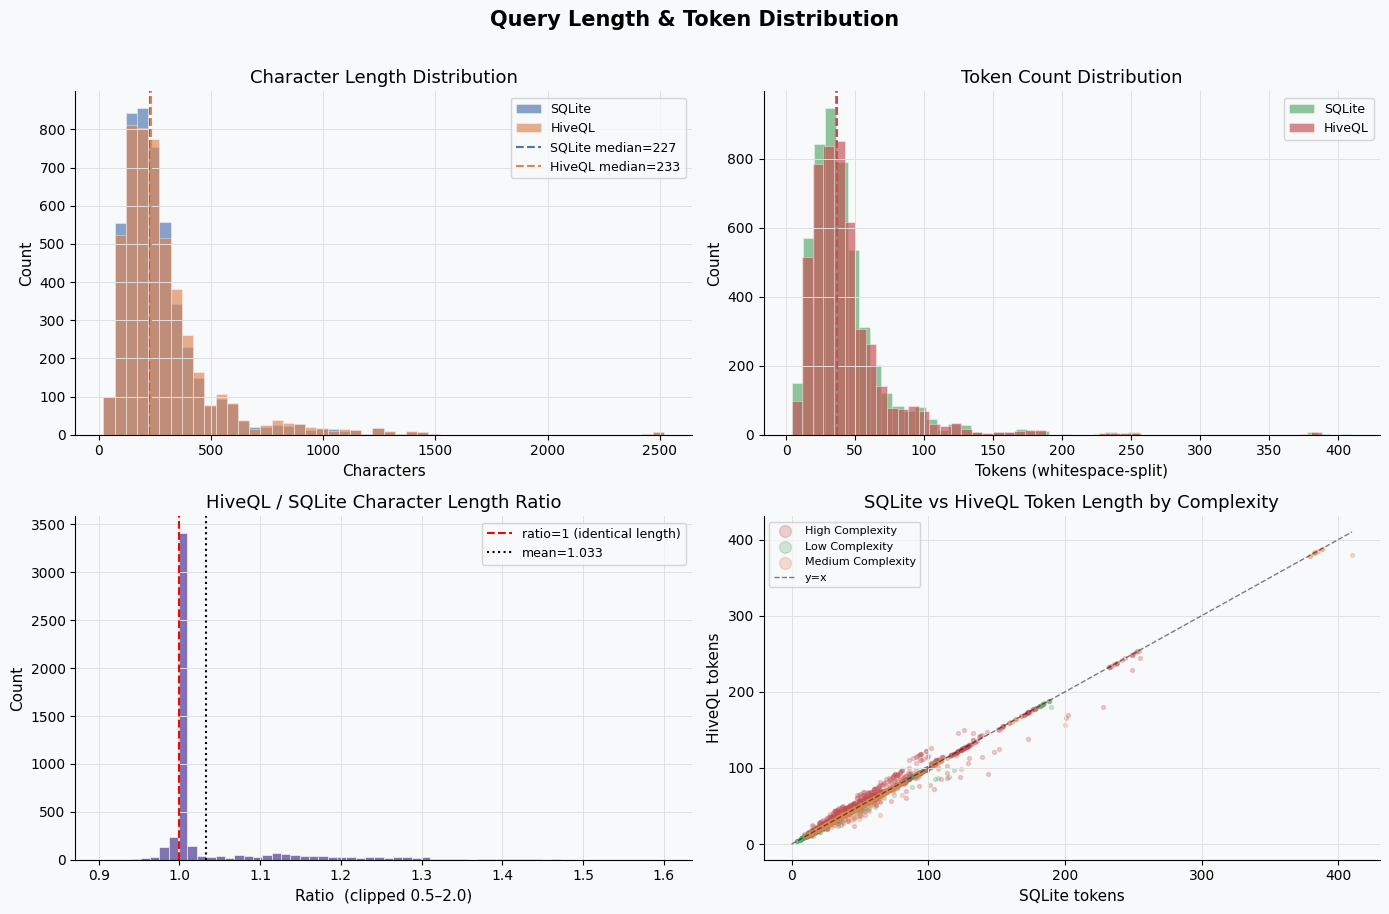

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Query Length & Token Distribution', fontsize=15, fontweight='bold', y=1.01)

# ── 2a: Character length distributions overlaid ───────────────────────────────
ax = axes[0, 0]
ax.hist(df['sqlite_char_len'], bins=50, alpha=0.65,
        color=PALETTE[0], label='SQLite', edgecolor='white', linewidth=0.4)
ax.hist(df['hive_char_len'],   bins=50, alpha=0.65,
        color=PALETTE[1], label='HiveQL', edgecolor='white', linewidth=0.4)
ax.axvline(df['sqlite_char_len'].median(), color=PALETTE[0],
           linestyle='--', linewidth=1.5, label=f'SQLite median={df["sqlite_char_len"].median():.0f}')
ax.axvline(df['hive_char_len'].median(),   color=PALETTE[1],
           linestyle='--', linewidth=1.5, label=f'HiveQL median={df["hive_char_len"].median():.0f}')
ax.set_title('Character Length Distribution')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 2b: Token length distributions ────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(df['sqlite_token_len'], bins=50, alpha=0.65,
        color=PALETTE[2], label='SQLite', edgecolor='white', linewidth=0.4)
ax.hist(df['hive_token_len'],   bins=50, alpha=0.65,
        color=PALETTE[3], label='HiveQL', edgecolor='white', linewidth=0.4)
ax.axvline(df['sqlite_token_len'].median(), color=PALETTE[2],
           linestyle='--', linewidth=1.5)
ax.axvline(df['hive_token_len'].median(),   color=PALETTE[3],
           linestyle='--', linewidth=1.5)
ax.set_title('Token Count Distribution')
ax.set_xlabel('Tokens (whitespace-split)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 2c: Character length ratio histogram ──────────────────────────────────────
ax = axes[1, 0]
clipped = df['len_ratio'].clip(0.5, 2.0)
ax.hist(clipped, bins=60, color=PALETTE[4], edgecolor='white', linewidth=0.4)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='ratio=1 (identical length)')
ax.axvline(df['len_ratio'].mean(), color='black',
           linestyle=':', linewidth=1.5, label=f'mean={df["len_ratio"].mean():.3f}')
ax.set_title('HiveQL / SQLite Character Length Ratio')
ax.set_xlabel('Ratio  (clipped 0.5–2.0)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 2d: Scatter SQLite vs HiveQL token length ─────────────────────────────────
ax = axes[1, 1]
colors_map = {'High Complexity': PALETTE[3],
              'Medium Complexity': PALETTE[1],
              'Low Complexity': PALETTE[2]}
for cmplx, grp in df.groupby('complexity'):
    ax.scatter(grp['sqlite_token_len'], grp['hive_token_len'],
               alpha=0.25, s=8, color=colors_map.get(cmplx, 'grey'),
               label=cmplx)
max_tok = max(df['sqlite_token_len'].max(), df['hive_token_len'].max())
ax.plot([0, max_tok], [0, max_tok], 'k--', linewidth=1, alpha=0.5, label='y=x')
ax.set_title('SQLite vs HiveQL Token Length by Complexity')
ax.set_xlabel('SQLite tokens')
ax.set_ylabel('HiveQL tokens')
ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
savefig('plot_01_length_distribution')

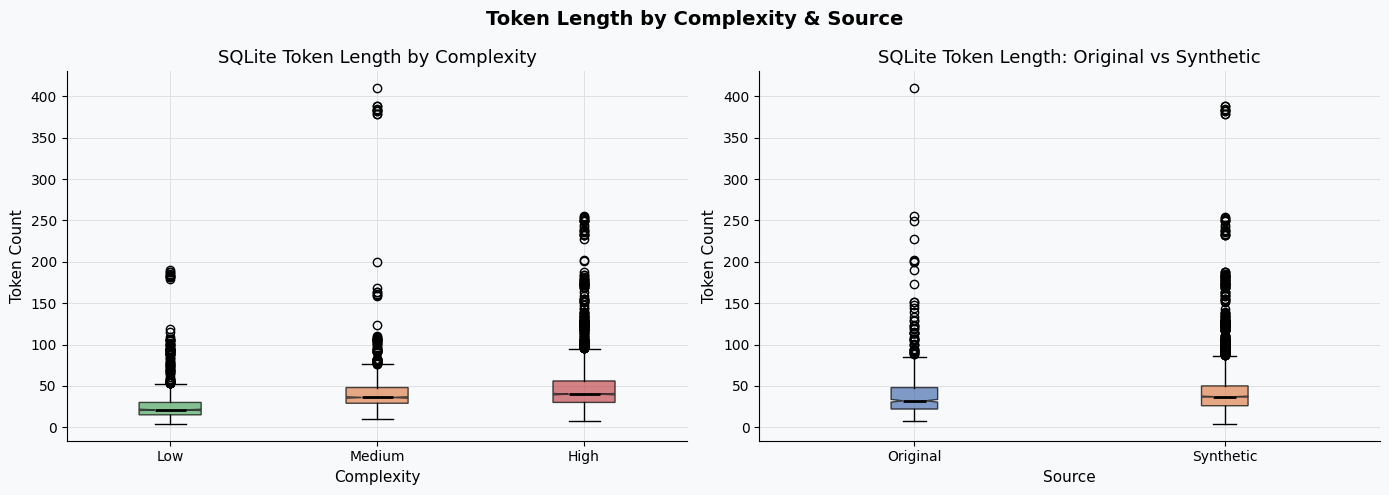

In [72]:
# ── Box plots: token length by complexity and source ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Token Length by Complexity & Source', fontsize=14, fontweight='bold')

# Box: SQLite token length by complexity
ax = axes[0]
order = ['Low Complexity', 'Medium Complexity', 'High Complexity']
data_by_cmplx = [df[df['complexity']==c]['sqlite_token_len'].values for c in order]
bp = ax.boxplot(data_by_cmplx, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [PALETTE[2], PALETTE[1], PALETTE[3]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_title('SQLite Token Length by Complexity')
ax.set_ylabel('Token Count')
ax.set_xlabel('Complexity')

# Box: token length by original vs synthetic
ax = axes[1]
data_by_src = [
    df[~df['is_synthetic']]['sqlite_token_len'].values,
    df[ df['is_synthetic']]['sqlite_token_len'].values,
]
bp2 = ax.boxplot(data_by_src, patch_artist=True, notch=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], [PALETTE[0], PALETTE[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Original', 'Synthetic'])
ax.set_title('SQLite Token Length: Original vs Synthetic')
ax.set_ylabel('Token Count')
ax.set_xlabel('Source')

plt.tight_layout()
savefig('plot_02_boxplots')

---
## 3. Complexity Distribution

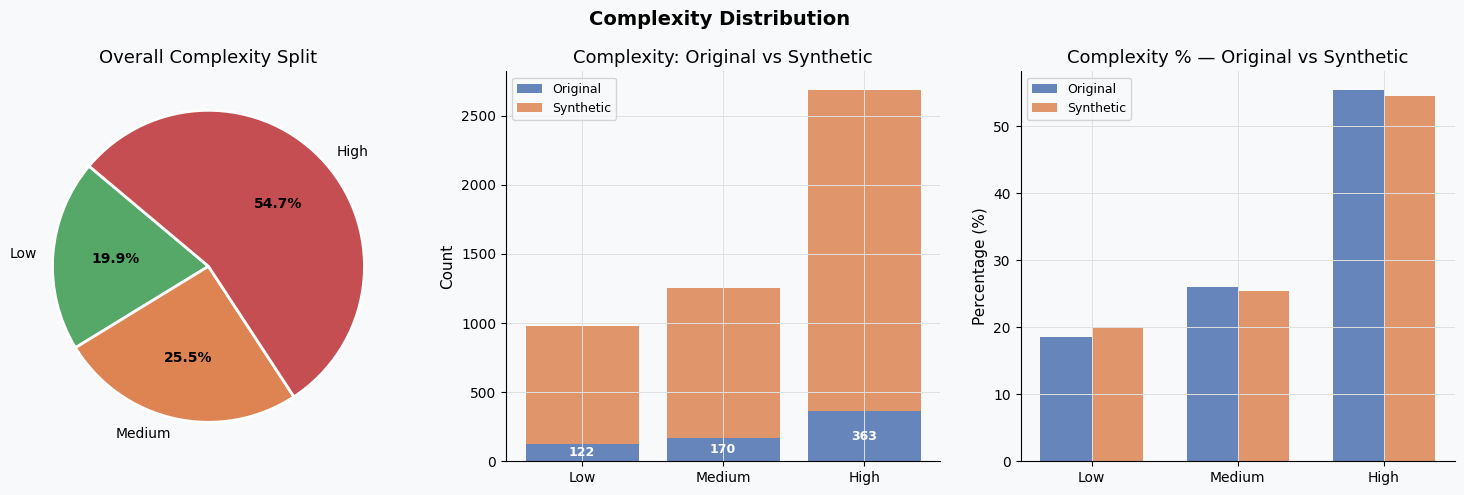

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Complexity Distribution', fontsize=14, fontweight='bold')

cmplx_order  = ['Low Complexity','Medium Complexity','High Complexity']
cmplx_labels = ['Low','Medium','High']
cmplx_colors = [PALETTE[2], PALETTE[1], PALETTE[3]]

# ── 3a: Overall pie ───────────────────────────────────────────────────────────
ax = axes[0]
counts = df['complexity'].value_counts().reindex(cmplx_order)
wedges, texts, autotexts = ax.pie(
    counts, labels=cmplx_labels, colors=cmplx_colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Overall Complexity Split')

# ── 3b: Stacked bar — original vs synthetic per complexity ────────────────────
ax = axes[1]
orig_counts  = df[~df['is_synthetic']]['complexity'].value_counts().reindex(cmplx_order, fill_value=0)
synth_counts = df[ df['is_synthetic']]['complexity'].value_counts().reindex(cmplx_order, fill_value=0)
x = np.arange(3)
b1 = ax.bar(x, orig_counts.values,  label='Original',  color=PALETTE[0], alpha=0.85)
b2 = ax.bar(x, synth_counts.values, bottom=orig_counts.values,
            label='Synthetic', color=PALETTE[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cmplx_labels)
ax.set_title('Complexity: Original vs Synthetic')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
for bar in b1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x()+bar.get_width()/2, h/2, str(int(h)),
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# ── 3c: Complexity proportion trend — original vs synthetic ───────────────────
ax = axes[2]
orig_pct  = (orig_counts  / orig_counts.sum()  * 100).round(1)
synth_pct = (synth_counts / synth_counts.sum() * 100).round(1)
x_pos = np.arange(3)
w = 0.35
ax.bar(x_pos - w/2, orig_pct.values,  w, label='Original',  color=PALETTE[0], alpha=0.85)
ax.bar(x_pos + w/2, synth_pct.values, w, label='Synthetic', color=PALETTE[1], alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(cmplx_labels)
ax.set_title('Complexity % — Original vs Synthetic')
ax.set_ylabel('Percentage (%)')
ax.legend(fontsize=9)

plt.tight_layout()
savefig('plot_03_complexity')

---
## 4. SQL Feature Coverage

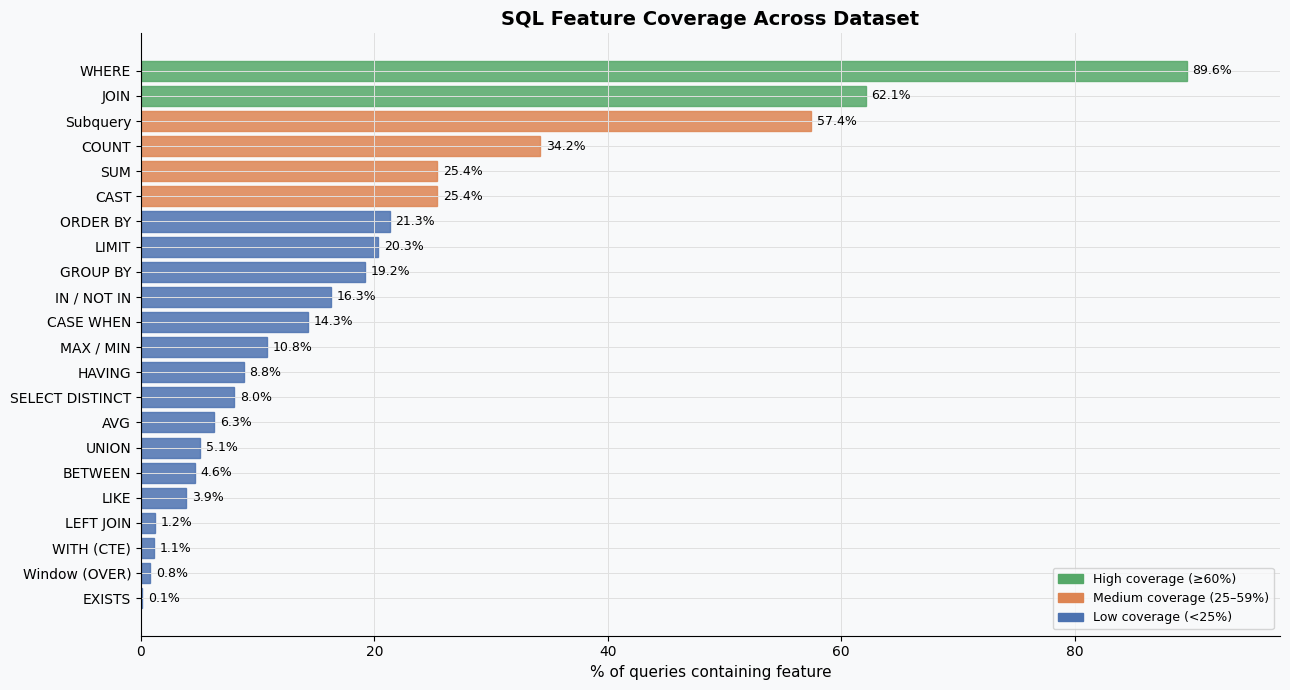

In [74]:
# ── Detect SQL features in each query ────────────────────────────────────────
SQL_FEATURES = {
    'SELECT DISTINCT' : r'\bselect\s+distinct\b',
    'WHERE'           : r'\bwhere\b',
    'JOIN'            : r'\bjoin\b',
    'LEFT JOIN'       : r'\bleft\s+join\b',
    'GROUP BY'        : r'\bgroup\s+by\b',
    'HAVING'          : r'\bhaving\b',
    'ORDER BY'        : r'\border\s+by\b',
    'LIMIT'           : r'\blimit\b',
    'Subquery'        : r'\bselect\b.*?\bfrom\b.*?\bselect\b',
    'WITH (CTE)'      : r'\bwith\b',
    'CAST'            : r'\bcast\s*\(',
    'CASE WHEN'       : r'\bcase\s+when\b',
    'COUNT'           : r'\bcount\s*\(',
    'SUM'             : r'\bsum\s*\(',
    'AVG'             : r'\bavg\s*\(',
    'MAX / MIN'       : r'\b(max|min)\s*\(',
    'LIKE'            : r'\blike\b',
    'IN / NOT IN'     : r'\b(not\s+)?in\s*\(',
    'BETWEEN'         : r'\bbetween\b',
    'EXISTS'          : r'\bexists\s*\(',
    'UNION'           : r'\bunion\b',
    'Window (OVER)'   : r'\bover\s*\(',
}

for feat, pattern in SQL_FEATURES.items():
    df[f'feat_{feat}'] = df['sqlite'].str.lower().str.contains(
        pattern, regex=True, na=False)

feat_cols   = [c for c in df.columns if c.startswith('feat_')]
feat_counts = df[feat_cols].sum().sort_values(ascending=False)
feat_labels = [c.replace('feat_','') for c in feat_counts.index]
feat_pcts   = (feat_counts / len(df) * 100).round(1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(feat_labels[::-1], feat_pcts.values[::-1],
               color=PALETTE[0], alpha=0.85, edgecolor='white')

# Colour-code by coverage tier
for bar, pct in zip(bars, feat_pcts.values[::-1]):
    if pct >= 60:
        bar.set_color(PALETTE[2])
    elif pct >= 25:
        bar.set_color(PALETTE[1])
    else:
        bar.set_color(PALETTE[0])
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

# Legend patches
patches = [
    mpatches.Patch(color=PALETTE[2], label='High coverage (≥60%)'),
    mpatches.Patch(color=PALETTE[1], label='Medium coverage (25–59%)'),
    mpatches.Patch(color=PALETTE[0], label='Low coverage (<25%)'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
ax.set_xlabel('% of queries containing feature')
ax.set_title('SQL Feature Coverage Across Dataset', fontsize=14, fontweight='bold')
ax.set_xlim(0, feat_pcts.max() + 8)
plt.tight_layout()
savefig('plot_04_sql_features')

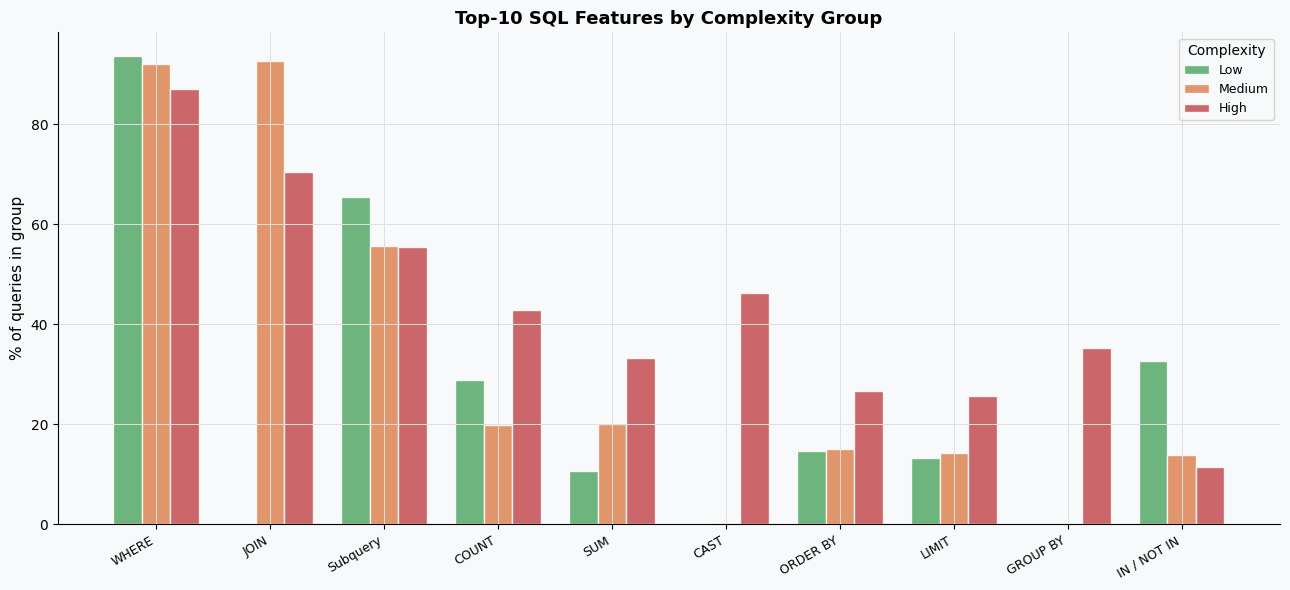

In [75]:
# ── Feature breakdown by complexity ──────────────────────────────────────────
top_feats = [c for c in feat_counts.head(10).index]
top_labels = [c.replace('feat_','') for c in top_feats]

fig, ax = plt.subplots(figsize=(13, 6))
x  = np.arange(len(top_feats))
w  = 0.25

for i, (cmplx, color) in enumerate(zip(cmplx_order, cmplx_colors)):
    sub = df[df['complexity'] == cmplx]
    pcts = [(sub[f].sum() / len(sub) * 100) for f in top_feats]
    ax.bar(x + i*w, pcts, w, label=cmplx.replace(' Complexity',''),
           color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels(top_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% of queries in group')
ax.set_title('Top-10 SQL Features by Complexity Group', fontsize=13, fontweight='bold')
ax.legend(title='Complexity', fontsize=9)
plt.tight_layout()
savefig('plot_05_features_by_complexity')

---
## 5. Schema & Table Analysis

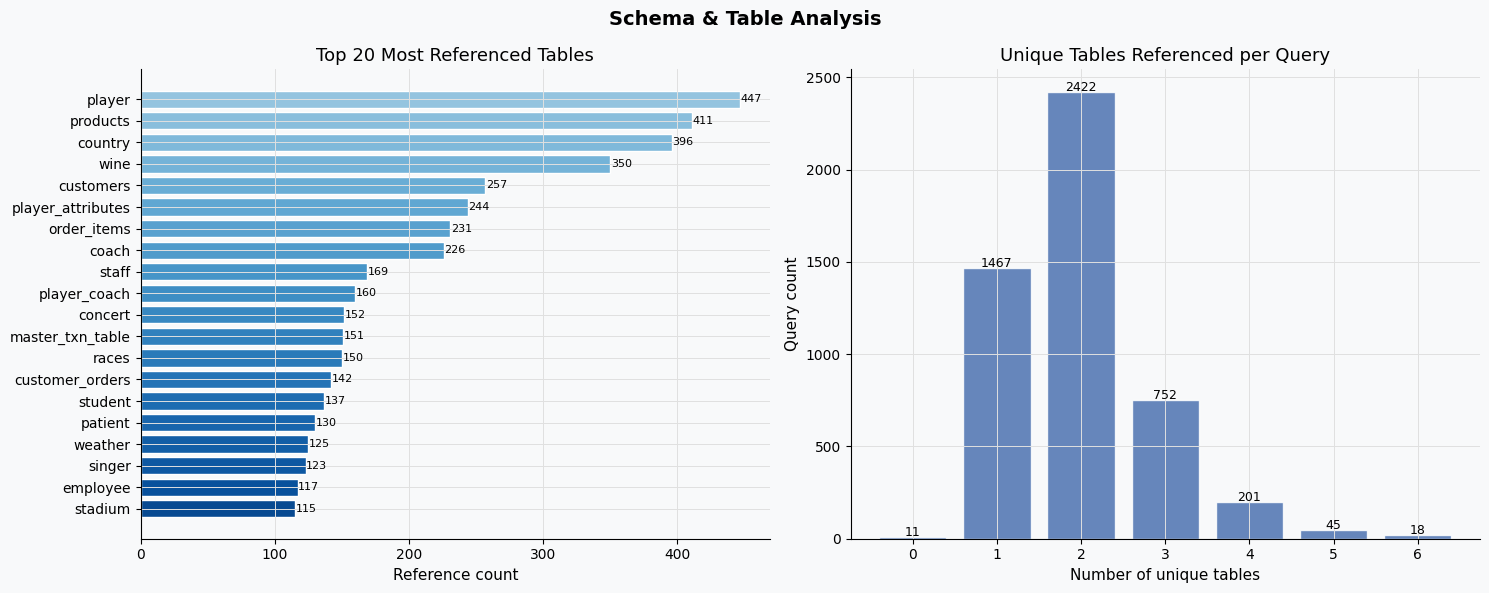

In [76]:
# ── Table frequency ───────────────────────────────────────────────────────────
all_tables = [t.lower() for tables in df['sqlite_tables'] for t in tables]
table_counts = Counter(all_tables).most_common(20)
t_names = [t for t, _ in table_counts]
t_vals  = [c for _, c in table_counts]

# ── Tables-per-query distribution ─────────────────────────────────────────────
df['n_tables'] = df['sqlite_tables'].apply(lambda x: len(set(t.lower() for t in x)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Schema & Table Analysis', fontsize=14, fontweight='bold')

# Top 20 tables bar
ax = axes[0]
cmap_vals = plt.cm.Blues(np.linspace(0.4, 0.9, len(t_vals)))
ax.barh(t_names[::-1], t_vals[::-1], color=cmap_vals[::-1], edgecolor='white')
ax.set_title('Top 20 Most Referenced Tables')
ax.set_xlabel('Reference count')
for i, v in enumerate(t_vals[::-1]):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=8)

# Tables per query distribution
ax = axes[1]
n_table_counts = df['n_tables'].value_counts().sort_index()
ax.bar(n_table_counts.index, n_table_counts.values,
       color=PALETTE[0], alpha=0.85, edgecolor='white')
ax.set_title('Unique Tables Referenced per Query')
ax.set_xlabel('Number of unique tables')
ax.set_ylabel('Query count')
for xi, yi in zip(n_table_counts.index, n_table_counts.values):
    ax.text(xi, yi + 5, str(yi), ha='center', fontsize=9)

plt.tight_layout()
savefig('plot_06_schema_analysis')

---
## 6. Translation Divergence Analysis

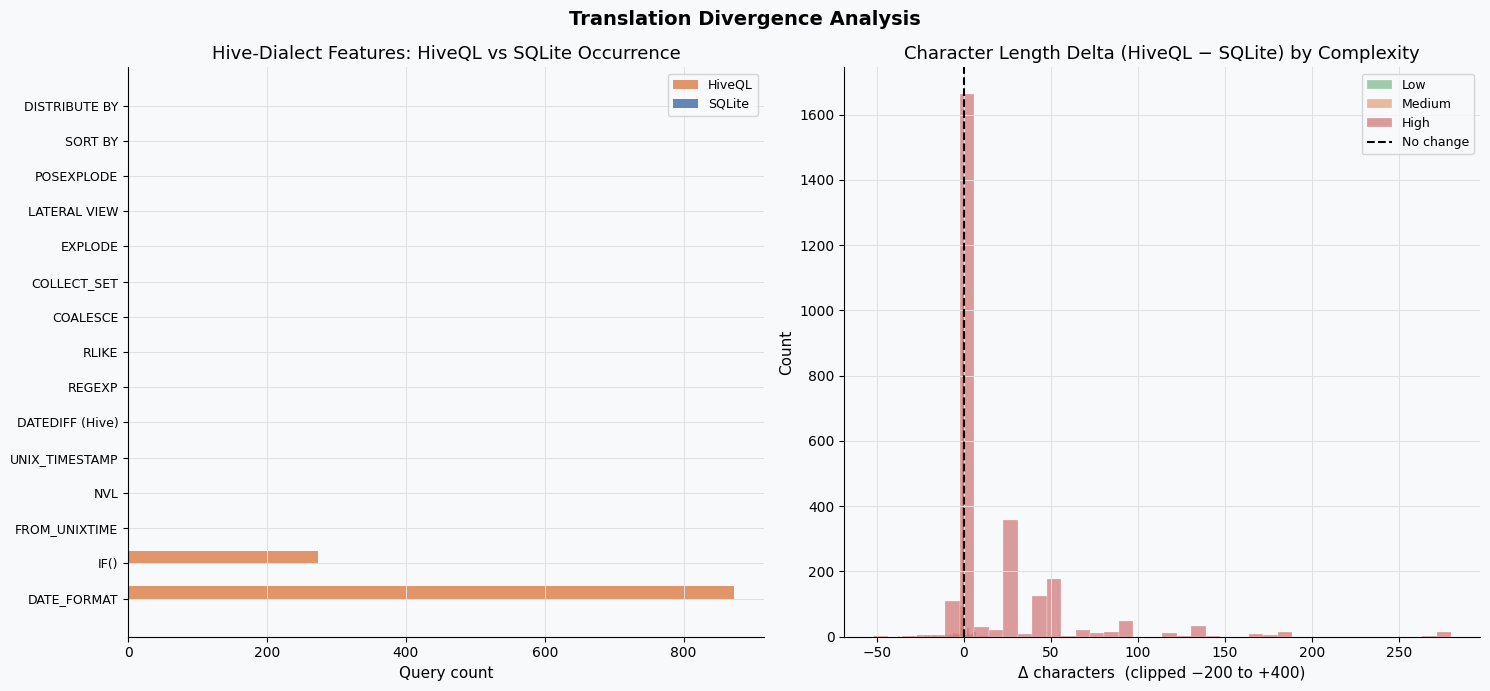

In [77]:
# ── Detect which dialect-specific functions appear in HiveQL but NOT SQLite ───
HIVE_PATTERNS = {
    'DATE_FORMAT'     : r'\bdate_format\b',
    'FROM_UNIXTIME'   : r'\bfrom_unixtime\b',
    'IF()'            : r'\bif\s*\(',
    'NVL'             : r'\bnvl\s*\(',
    'UNIX_TIMESTAMP'  : r'\bunix_timestamp\b',
    'DATEDIFF (Hive)' : r'\bdatediff\b',
    'REGEXP'          : r'\bregexp\b',
    'RLIKE'           : r'\brlike\b',
    'COALESCE'        : r'\bcoalesce\b',
    'COLLECT_SET'     : r'\bcollect_set\b',
    'EXPLODE'         : r'\bexplode\b',
    'LATERAL VIEW'    : r'\blateral\s+view\b',
    'POSEXPLODE'      : r'\bposexplode\b',
    'SORT BY'         : r'\bsort\s+by\b',
    'DISTRIBUTE BY'   : r'\bdistribute\s+by\b',
}

hive_feat_data = {}
for feat, pat in HIVE_PATTERNS.items():
    in_hive   = df['hive'].str.lower().str.contains(pat, regex=True, na=False).sum()
    in_sqlite = df['sqlite'].str.lower().str.contains(pat, regex=True, na=False).sum()
    hive_feat_data[feat] = {'HiveQL': in_hive, 'SQLite': in_sqlite}

hive_feat_df = pd.DataFrame(hive_feat_data).T.sort_values('HiveQL', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Translation Divergence Analysis', fontsize=14, fontweight='bold')

# Hive-specific feature counts
ax = axes[0]
y  = np.arange(len(hive_feat_df))
w  = 0.35
ax.barh(y + w/2, hive_feat_df['HiveQL'], w,  label='HiveQL',  color=PALETTE[1], alpha=0.85)
ax.barh(y - w/2, hive_feat_df['SQLite'], w,  label='SQLite',  color=PALETTE[0], alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(hive_feat_df.index, fontsize=9)
ax.set_title('Hive-Dialect Features: HiveQL vs SQLite Occurrence')
ax.set_xlabel('Query count')
ax.legend(fontsize=9)

# Character-length delta distribution by complexity
ax = axes[1]
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = df[df['complexity']==cmplx]['len_diff_chars'].clip(-200, 400)
    ax.hist(sub, bins=40, alpha=0.55, color=color,
            label=cmplx.replace(' Complexity',''), edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='No change')
ax.set_title('Character Length Delta (HiveQL − SQLite) by Complexity')
ax.set_xlabel('Δ characters  (clipped −200 to +400)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

plt.tight_layout()
savefig('plot_07_translation_divergence')

---
## 7. Data Quality Checks

In [78]:
# ── Run all quality checks and collect results ─────────────────────────────────
quality_results = {}

# Q1: Missing values
quality_results['Missing SQLite']  = df['sqlite'].isna().sum()
quality_results['Missing HiveQL']  = df['hive'].isna().sum()

# Q2: Empty strings
quality_results['Empty SQLite']    = (df['sqlite'].str.strip() == '').sum()
quality_results['Empty HiveQL']    = (df['hive'].str.strip()   == '').sum()

# Q3: Exact duplicates
quality_results['Exact dup pairs'] = df.duplicated(subset=['sqlite','hive']).sum()

# Q4: Queries not starting with SELECT
quality_results['Non-SELECT SQLite'] = (~df['sqlite'].str.strip().str.upper().str.startswith('SELECT')).sum()
quality_results['Non-SELECT HiveQL'] = (~df['hive'].str.strip().str.upper().str.startswith('SELECT')).sum()

# Q5: Parse failures
def count_parse_failures(series, dialect):
    fails = 0
    for sql in series:
        try:
            sqlglot.parse_one(str(sql), read=dialect)
        except Exception:
            fails += 1
    return fails

print('Running parse checks (this may take ~30s)...')
quality_results['SQLite parse fails'] = count_parse_failures(df['sqlite'], 'sqlite')
quality_results['HiveQL parse fails'] = count_parse_failures(df['hive'],   'hive')

# Q6: Encoding issues
def has_encoding_issue(text):
    try:
        str(text).encode('utf-8').decode('utf-8')
        return False
    except Exception:
        return True

quality_results['Encoding issues SQLite'] = df['sqlite'].apply(has_encoding_issue).sum()
quality_results['Encoding issues HiveQL'] = df['hive'].apply(has_encoding_issue).sum()

# Q7: Suspiciously short queries (< 10 chars)
quality_results['SQLite < 10 chars']  = (df['sqlite_char_len'] < 10).sum()
quality_results['HiveQL < 10 chars']  = (df['hive_char_len']   < 10).sum()

# Q8: Suspiciously long queries (> 2000 chars)
quality_results['SQLite > 2000 chars'] = (df['sqlite_char_len'] > 2000).sum()
quality_results['HiveQL > 2000 chars'] = (df['hive_char_len']   > 2000).sum()

# Q9: Identical source and target
quality_results['SQLite == HiveQL (identical)'] = (
    df['sqlite'].str.strip().str.lower() == df['hive'].str.strip().str.lower()).sum()

# Display
qdf = pd.DataFrame.from_dict(quality_results, orient='index', columns=['Count'])
qdf['% of total'] = (qdf['Count'] / len(df) * 100).round(3)
qdf['Status'] = qdf['Count'].apply(
    lambda x: '✅ OK' if x == 0 else ('⚠️ Warn' if x < len(df)*0.01 else '❌ Issue')
)
print('\n── DATA QUALITY RESULTS ──')
print(qdf.to_string())

Running parse checks (this may take ~30s)...

── DATA QUALITY RESULTS ──
                              Count  % of total   Status
Missing SQLite                    0       0.000     ✅ OK
Missing HiveQL                    0       0.000     ✅ OK
Empty SQLite                      0       0.000     ✅ OK
Empty HiveQL                      0       0.000     ✅ OK
Exact dup pairs                   0       0.000     ✅ OK
Non-SELECT SQLite                46       0.936  ⚠️ Warn
Non-SELECT HiveQL                65       1.322  ❌ Issue
SQLite parse fails                0       0.000     ✅ OK
HiveQL parse fails                1       0.020  ⚠️ Warn
Encoding issues SQLite            0       0.000     ✅ OK
Encoding issues HiveQL            0       0.000     ✅ OK
SQLite < 10 chars                 0       0.000     ✅ OK
HiveQL < 10 chars                 0       0.000     ✅ OK
SQLite > 2000 chars              10       0.203  ⚠️ Warn
HiveQL > 2000 chars              10       0.203  ⚠️ Warn
SQLite == HiveQ

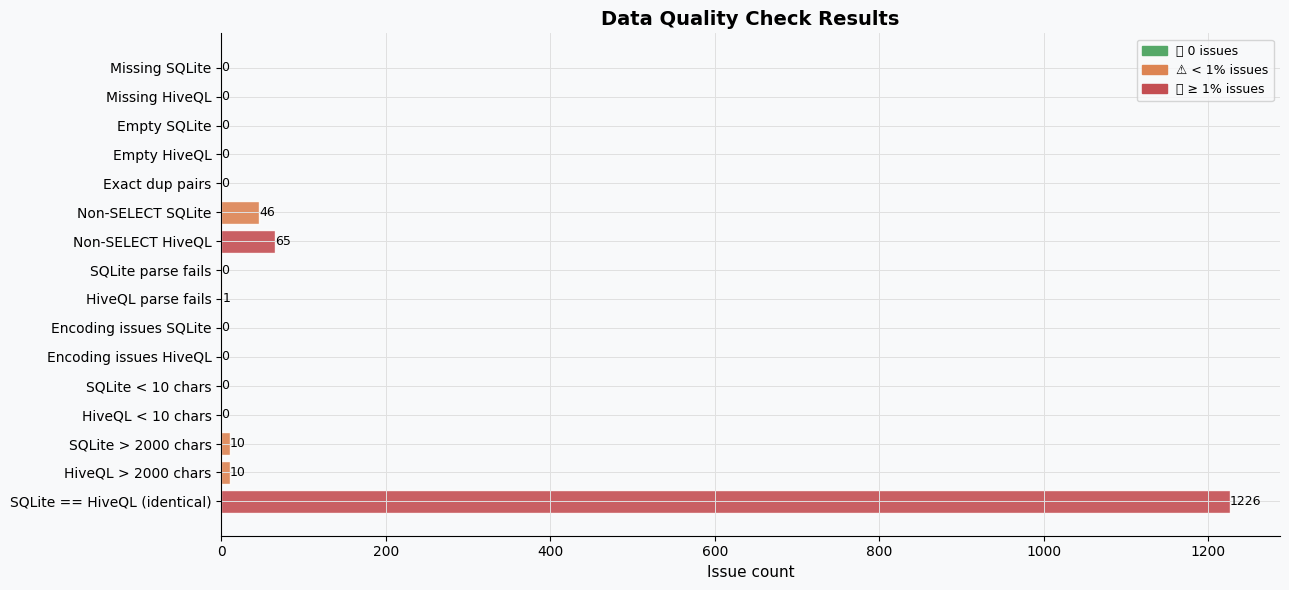

In [79]:
# ── Quality check bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

bar_colors = []
for v in qdf['Count']:
    if v == 0:
        bar_colors.append(PALETTE[2])       # green
    elif v < len(df) * 0.01:
        bar_colors.append(PALETTE[1])       # orange
    else:
        bar_colors.append(PALETTE[3])       # red

bars = ax.barh(qdf.index[::-1], qdf['Count'].values[::-1],
               color=bar_colors[::-1], edgecolor='white', alpha=0.9)

for bar, val in zip(bars, qdf['Count'].values[::-1]):
    ax.text(max(val + 0.3, 0.3), bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)

patches = [
    mpatches.Patch(color=PALETTE[2], label='✅ 0 issues'),
    mpatches.Patch(color=PALETTE[1], label='⚠️ < 1% issues'),
    mpatches.Patch(color=PALETTE[3], label='❌ ≥ 1% issues'),
]
ax.legend(handles=patches, fontsize=9)
ax.set_title('Data Quality Check Results', fontsize=14, fontweight='bold')
ax.set_xlabel('Issue count')
plt.tight_layout()
savefig('plot_08_quality_checks')

---
## 8. Advanced: AST Depth Distribution

In [80]:
# ── Compute AST depth for every query ─────────────────────────────────────────
def ast_depth(sql, dialect='sqlite'):
    """Return the maximum depth of the sqlglot AST tree."""
    try:
        tree = sqlglot.parse_one(sql, read=dialect)
        if tree is None:
            return np.nan

        def _depth(node, d=0):
            children = list(node.args.values())
            children = [c for c in children if isinstance(c, exp.Expression)]
            if not children:
                return d
            return max(_depth(c, d+1) for c in children)

        return _depth(tree)
    except Exception:
        return np.nan

print('Computing AST depths (takes ~1–2 min)...')
df['ast_depth_sqlite'] = df['sqlite'].apply(lambda s: ast_depth(s, 'sqlite'))
df['ast_depth_hive']   = df['hive'].apply(  lambda s: ast_depth(s, 'hive'))

print(f'SQLite AST depth  — mean: {df["ast_depth_sqlite"].mean():.2f},  '
      f'max: {df["ast_depth_sqlite"].max()}')
print(f'HiveQL AST depth  — mean: {df["ast_depth_hive"].mean():.2f},  '
      f'max: {df["ast_depth_hive"].max()}')

Computing AST depths (takes ~1–2 min)...
SQLite AST depth  — mean: 7.41,  max: 29
HiveQL AST depth  — mean: 7.53,  max: 29.0


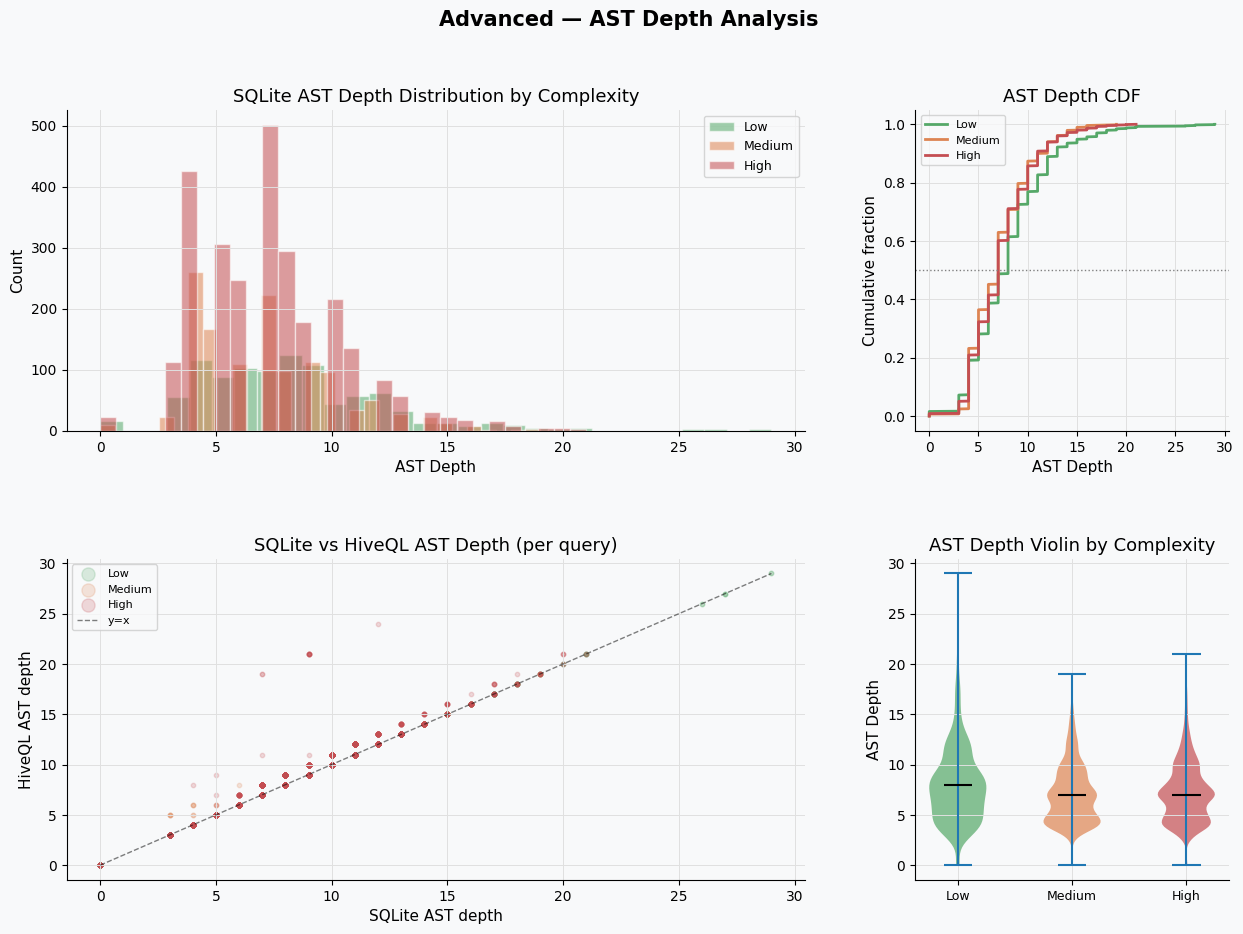

In [81]:
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Advanced — AST Depth Analysis', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 8a: AST depth histogram by complexity ────────────────────────────────────
ax = fig.add_subplot(gs[0, :2])
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = df[df['complexity']==cmplx]['ast_depth_sqlite'].dropna()
    ax.hist(sub, bins=30, alpha=0.55, color=color,
            label=cmplx.replace(' Complexity',''), edgecolor='white')
ax.set_title('SQLite AST Depth Distribution by Complexity')
ax.set_xlabel('AST Depth')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 8b: AST depth CDF (cumulative) ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = df[df['complexity']==cmplx]['ast_depth_sqlite'].dropna().sort_values()
    ax.plot(sub.values, np.linspace(0,1,len(sub)),
            color=color, linewidth=2,
            label=cmplx.replace(' Complexity',''))
ax.set_title('AST Depth CDF')
ax.set_xlabel('AST Depth')
ax.set_ylabel('Cumulative fraction')
ax.legend(fontsize=8)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1)

# ── 8c: AST depth scatter: SQLite vs HiveQL ───────────────────────────────────
ax = fig.add_subplot(gs[1, :2])
valid = df[['ast_depth_sqlite','ast_depth_hive','complexity']].dropna()
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = valid[valid['complexity']==cmplx]
    ax.scatter(sub['ast_depth_sqlite'], sub['ast_depth_hive'],
               alpha=0.2, s=10, color=color,
               label=cmplx.replace(' Complexity',''))
max_d = max(valid['ast_depth_sqlite'].max(), valid['ast_depth_hive'].max())
ax.plot([0,max_d],[0,max_d],'k--',linewidth=1,alpha=0.5, label='y=x')
ax.set_title('SQLite vs HiveQL AST Depth (per query)')
ax.set_xlabel('SQLite AST depth')
ax.set_ylabel('HiveQL AST depth')
ax.legend(fontsize=8, markerscale=3)

# ── 8d: Mean AST depth per complexity (violin) ───────────────────────────────
ax = fig.add_subplot(gs[1, 2])
violin_data = [df[df['complexity']==c]['ast_depth_sqlite'].dropna().values
               for c in cmplx_order]
parts = ax.violinplot(violin_data, positions=[1,2,3],
                      showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], cmplx_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
ax.set_xticks([1,2,3])
ax.set_xticklabels(['Low','Medium','High'], fontsize=9)
ax.set_title('AST Depth Violin by Complexity')
ax.set_ylabel('AST Depth')

savefig('plot_09_ast_depth')

---
## 9. Advanced: SQL Feature Co-occurrence Heatmap

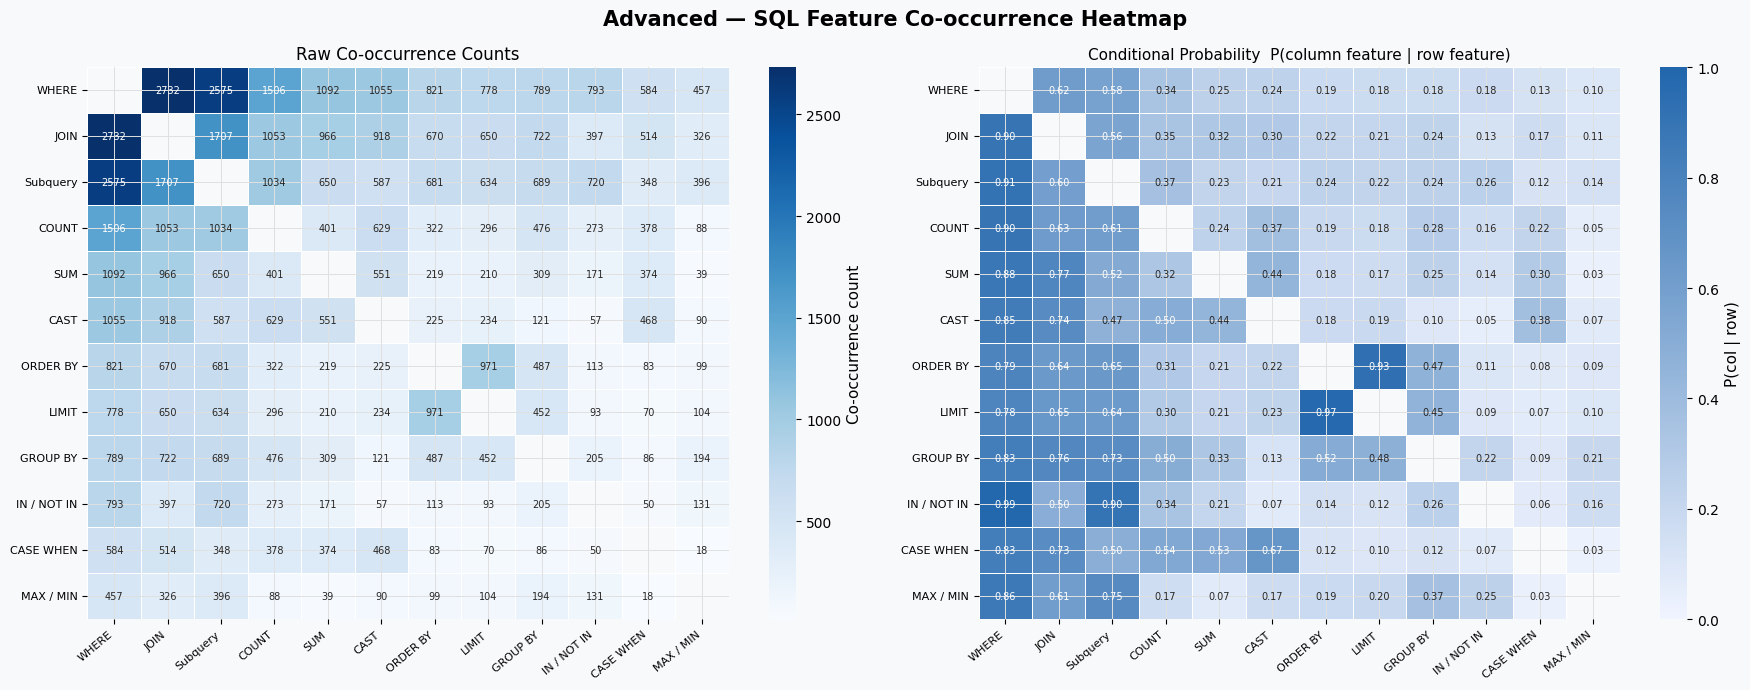

In [82]:
# ── Build co-occurrence matrix for top SQL features ───────────────────────────
TOP_N      = 12
top_feat_cols = [c for c in feat_counts.head(TOP_N).index]
top_feat_names = [c.replace('feat_','') for c in top_feat_cols]

feat_matrix = df[top_feat_cols].astype(int)

# Co-occurrence: how often do feature i and feature j appear together?
cooc = feat_matrix.T.dot(feat_matrix)
cooc.index   = top_feat_names
cooc.columns = top_feat_names

# Normalise to conditional probability: P(j | i) = cooc[i][j] / cooc[i][i]
diag = np.diag(cooc.values)
cooc_norm = cooc.values / diag[:, None]   # row-normalised
np.fill_diagonal(cooc_norm, np.nan)       # mask the diagonal

# ── Plot heatmap ──────────────────────────────────────────────────────────────
custom_cmap = LinearSegmentedColormap.from_list(
    'custom_blues', ['#F0F4FF','#2166AC'], N=256)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Advanced — SQL Feature Co-occurrence Heatmap', fontsize=15, fontweight='bold')

# Raw co-occurrence counts
ax = axes[0]
mask = np.eye(TOP_N, dtype=bool)
sns.heatmap(
    cooc, ax=ax, cmap='Blues', mask=mask,
    annot=True, fmt='d', annot_kws={'size':7},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label':'Co-occurrence count'}
)
ax.set_title('Raw Co-occurrence Counts', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)

# Normalised: P(col feature | row feature present)
ax = axes[1]
cooc_norm_df = pd.DataFrame(cooc_norm, index=top_feat_names, columns=top_feat_names)
sns.heatmap(
    cooc_norm_df, ax=ax, cmap=custom_cmap, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size':7},
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label':'P(col | row)'}
)
ax.set_title('Conditional Probability  P(column feature | row feature)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.tight_layout()
savefig('plot_10_cooccurrence_heatmap')

---
## 10. Quality Summary Scorecard

In [83]:
# ── Compute dimension scores ───────────────────────────────────────────────────
total = len(df)

def score(passed, total, weight=1.0):
    return round((passed / total) * 100 * weight, 1)

scores = {
    'Completeness'      : score(total - quality_results['Missing SQLite']
                                      - quality_results['Missing HiveQL'],
                                total * 2),
    'No Duplicates'     : score(total - quality_results['Exact dup pairs'], total),
    'Parse Validity'    : score(total - quality_results['SQLite parse fails']
                                      - quality_results['HiveQL parse fails'],
                                total * 2),
    'Length Sanity'     : score(total - quality_results['SQLite < 10 chars']
                                      - quality_results['SQLite > 2000 chars'],
                                total),
    'Encoding OK'       : score(total - quality_results['Encoding issues SQLite']
                                      - quality_results['Encoding issues HiveQL'],
                                total * 2),
    'Translation Diff'  : score(total - quality_results['SQLite == HiveQL (identical)'],
                                total),
    'Complexity Balance': min(100.0, round(
        100 - abs(df['complexity'].value_counts(normalize=True).std() * 300), 1)),
    'Feature Diversity' : min(100.0, round(
        (df[feat_cols].any(axis=1).sum() / total) * 100, 1)),
}

overall = round(sum(scores.values()) / len(scores), 1)

score_df = pd.DataFrame.from_dict(scores, orient='index', columns=['Score'])
score_df['Grade'] = score_df['Score'].apply(
    lambda x: 'A' if x>=90 else ('B' if x>=75 else ('C' if x>=60 else 'D')))

print('\n── QUALITY SCORECARD ──')
print(score_df.to_string())
print(f'\n  Overall Score: {overall}/100')


── QUALITY SCORECARD ──
                    Score Grade
Completeness         50.0     D
No Duplicates       100.0     A
Parse Validity       50.0     D
Length Sanity        99.8     A
Encoding OK          50.0     D
Translation Diff     75.1     B
Complexity Balance   44.0     D
Feature Diversity    99.7     A

  Overall Score: 71.1/100


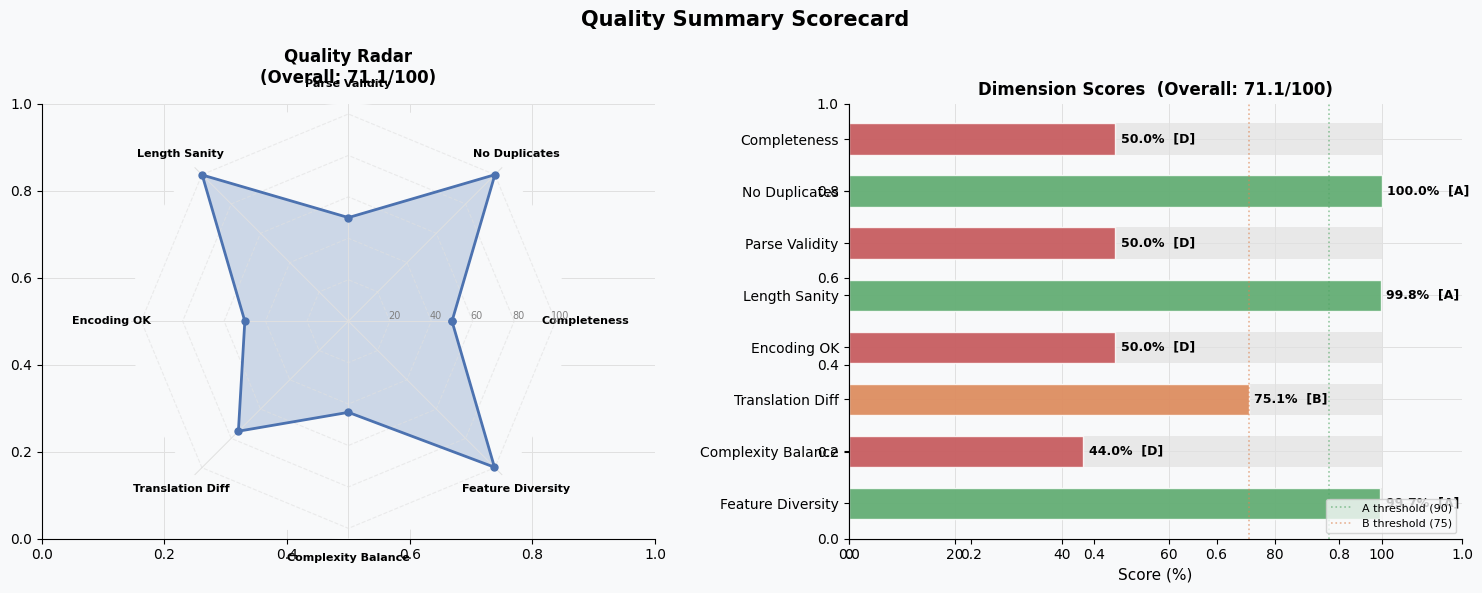

In [84]:
# ── Radar / Spider chart for the scorecard ────────────────────────────────────
labels  = list(scores.keys())
values  = list(scores.values())
N       = len(labels)
angles  = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]      # close the polygon
values_plot = values + values[:1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                          subplot_kw=dict(polar=True) if False else {})
fig.suptitle('Quality Summary Scorecard', fontsize=15, fontweight='bold')

# ── Radar chart ──────────────────────────────────────────────────────────────
ax_radar = fig.add_subplot(121, polar=True)
ax_radar.set_facecolor(BG)

# Rings
for r in [20, 40, 60, 80, 100]:
    ax_radar.plot(angles, [r]*(N+1), '--', color=GRID_CLR, linewidth=0.8, alpha=0.6)
    ax_radar.text(0, r+2, str(r), ha='center', va='bottom', fontsize=7, color='grey')

# Fill
ax_radar.fill(angles, values_plot, alpha=0.25, color=PALETTE[0])
ax_radar.plot(angles, values_plot, 'o-', color=PALETTE[0], linewidth=2, markersize=5)

# Labels
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(labels, fontsize=8, fontweight='bold')
ax_radar.set_ylim(0, 105)
ax_radar.set_yticks([])
ax_radar.set_title(f'Quality Radar\n(Overall: {overall}/100)',
                   fontsize=12, fontweight='bold', pad=15)
ax_radar.spines['polar'].set_visible(False)

# ── Horizontal bar scorecard ──────────────────────────────────────────────────
ax2 = fig.add_subplot(122)
ax2.set_facecolor(BG)

bar_clrs = [PALETTE[2] if v>=90 else (PALETTE[1] if v>=75 else PALETTE[3])
            for v in values]
bars = ax2.barh(labels[::-1], values[::-1],
                color=bar_clrs[::-1], alpha=0.85, edgecolor='white', height=0.6)

# Background full bars (grey)
ax2.barh(labels[::-1], [100]*N, color='#E8E8E8', height=0.6, zorder=0)
for bar, v in zip(bars, values[::-1]):
    grade = 'A' if v>=90 else ('B' if v>=75 else ('C' if v>=60 else 'D'))
    ax2.text(v + 1, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}%  [{grade}]', va='center', fontsize=9, fontweight='bold')

ax2.axvline(90, color=PALETTE[2], linestyle=':', linewidth=1.2, alpha=0.6, label='A threshold (90)')
ax2.axvline(75, color=PALETTE[1], linestyle=':', linewidth=1.2, alpha=0.6, label='B threshold (75)')
ax2.set_xlim(0, 115)
ax2.set_xlabel('Score (%)')
ax2.set_title(f'Dimension Scores  (Overall: {overall}/100)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, axis='x', color=GRID_CLR)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
savefig('plot_11_quality_scorecard')

In [86]:
# ── Final EDA summary printout ────────────────────────────────────────────────
print('═'*60)
print('  EDA COMPLETE — PLOTS GENERATED')
print('═'*60)
plots = [
    ('plot_01', 'Query length & token distributions'),
    ('plot_02', 'Token length box plots'),
    ('plot_03', 'Complexity distribution (pie + bar)'),
    ('plot_04', 'SQL feature coverage'),
    ('plot_05', 'Feature coverage by complexity'),
    ('plot_06', 'Schema & table analysis'),
    ('plot_07', 'Translation divergence analysis'),
    ('plot_08', 'Data quality check results'),
    ('plot_09', 'AST depth analysis  [Advanced]'),
    ('plot_10', 'Feature co-occurrence heatmap  [Advanced]'),
    ('plot_11', 'Quality scorecard radar + bar'),
]
for fname, desc in plots:
    print(f'  {fname}.png  →  {desc}')
print('─'*60)
print(f'  Overall quality score : {overall}/100')
print(f'  Dataset ready for split: {overall >= 70}')
print('═'*60)

════════════════════════════════════════════════════════════
  EDA COMPLETE — PLOTS GENERATED
════════════════════════════════════════════════════════════
  plot_01.png  →  Query length & token distributions
  plot_02.png  →  Token length box plots
  plot_03.png  →  Complexity distribution (pie + bar)
  plot_04.png  →  SQL feature coverage
  plot_05.png  →  Feature coverage by complexity
  plot_06.png  →  Schema & table analysis
  plot_07.png  →  Translation divergence analysis
  plot_08.png  →  Data quality check results
  plot_09.png  →  AST depth analysis  [Advanced]
  plot_10.png  →  Feature co-occurrence heatmap  [Advanced]
  plot_11.png  →  Quality scorecard radar + bar
────────────────────────────────────────────────────────────
  Overall quality score : 71.1/100
  Dataset ready for split: True
════════════════════════════════════════════════════════════


##Dataset Split

In [88]:
# ── §6.4 Stratified split ─────────────────────────────────────────────────────
train_r = aug_config['train_ratio']
val_r   = aug_config['val_ratio']
test_r  = round(1 - train_r - val_r, 4)

group_df = (
    augmented_df
    .groupby('group_id')
    .agg(majority_complexity=('complexity', lambda x: x.mode()[0]))
    .reset_index()
)

train_groups, temp_groups = train_test_split(
    group_df,
    test_size=round(val_r + test_r, 4),
    stratify=group_df['majority_complexity'],
    random_state=aug_config['random_seed']
)

val_fraction_of_temp = val_r / (val_r + test_r)
val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=round(1 - val_fraction_of_temp, 4),
    stratify=temp_groups['majority_complexity'],
    random_state=aug_config['random_seed']
)

split_map = {}
for gid in train_groups['group_id']: split_map[gid] = 'train'
for gid in val_groups['group_id']:   split_map[gid] = 'val'
for gid in test_groups['group_id']:  split_map[gid] = 'test'

augmented_df['split'] = augmented_df['group_id'].map(split_map)

total = len(augmented_df)
print('Split counts:')
for s in ['train', 'val', 'test']:
    n = (augmented_df['split'] == s).sum()
    print(f'  {s:5s}  {n:5,}  ({100*n/total:.1f}%)')

Split counts:
  train  3,003  (61.1%)
  val      983  (20.0%)
  test     930  (18.9%)


In [89]:
# ── Verify complexity balance ──────────────────────────────────────────────────
sc = (augmented_df
      .groupby(['split','complexity'])
      .size()
      .unstack(fill_value=0))
print('Complexity count per split:')
print(sc)
print()
print('Complexity % per split:')
print(sc.div(sc.sum(axis=1), axis=0).round(3))

Complexity count per split:
complexity  High Complexity  Low Complexity  Medium Complexity
split                                                         
test                    507             192                231
train                  1615             599                789
val                     565             185                233

Complexity % per split:
complexity  High Complexity  Low Complexity  Medium Complexity
split                                                         
test                  0.545           0.206              0.248
train                 0.538           0.199              0.263
val                   0.575           0.188              0.237


In [90]:
# ── Cross-split leakage assertion ─────────────────────────────────────────────
h = {s: set(augmented_df.loc[augmented_df['split']==s, 'pair_hash'])
     for s in ['train','val','test']}

leaks = {
    'train∩val' : len(h['train'] & h['val']),
    'train∩test': len(h['train'] & h['test']),
    'val∩test'  : len(h['val']   & h['test']),
}
for label, n in leaks.items():
    print(f'{label} leakage: {n}')
assert all(v == 0 for v in leaks.values()), 'Leakage detected!'
print('✓ Zero cross-split hash leakage.')

train∩val leakage: 0
train∩test leakage: 0
val∩test leakage: 0
✓ Zero cross-split hash leakage.


In [91]:
# ── Export ────────────────────────────────────────────────────────────────────
out_cols = ['sqlite', 'hive', 'complexity', 'is_synthetic', 'split']

train_df = augmented_df[augmented_df['split']=='train'][out_cols].reset_index(drop=True)
val_df   = augmented_df[augmented_df['split']=='val'  ][out_cols].reset_index(drop=True)
test_df  = augmented_df[augmented_df['split']=='test' ][out_cols].reset_index(drop=True)

train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv',     index=False)
test_df.to_csv('test.csv',   index=False)

print('Saved  train.csv  val.csv  test.csv')

Saved  train.csv  val.csv  test.csv


In [92]:
# ── Final summary card ────────────────────────────────────────────────────────
print('═'*58)
print('  AUGMENTATION & SPLIT PIPELINE  –  SUMMARY')
print('═'*58)
print(f'  Config: target_rows     = {aug_config["tgt_rows"]:,}')
print(f'  Config: max_chains      = {aug_config["max_chains"]}')
print(f'  Config: chain_lengths   = {aug_config["chain_lengths"]}')
print(f'  Config: transforms used = {len(ACTIVE_TRANSFORMS)}')
print('─'*58)
orig  = (~augmented_df['is_synthetic']).sum()
synth = augmented_df['is_synthetic'].sum()
total = len(augmented_df)
print(f'  Original pairs          : {orig:>6,}')
print(f'  Synthetic pairs         : {synth:>6,}')
print(f'  Total (after dedup)     : {total:>6,}')
print('─'*58)
for s in ['train','val','test']:
    n = (augmented_df['split']==s).sum()
    print(f'  {s:5s} split             : {n:>6,}  ({100*n/total:.1f}%)')
print('═'*58)

══════════════════════════════════════════════════════════
  AUGMENTATION & SPLIT PIPELINE  –  SUMMARY
══════════════════════════════════════════════════════════
  Config: target_rows     = 5,000
  Config: max_chains      = 12
  Config: chain_lengths   = [1, 2, 3]
  Config: transforms used = 7
──────────────────────────────────────────────────────────
  Original pairs          :    655
  Synthetic pairs         :  4,261
  Total (after dedup)     :  4,916
──────────────────────────────────────────────────────────
  train split             :  3,003  (61.1%)
  val   split             :    983  (20.0%)
  test  split             :    930  (18.9%)
══════════════════════════════════════════════════════════
